In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, 
                             precision_score, recall_score)

# load classification dataset
df_classification = pd.read_csv('df_classification.csv')

print(f"Shape: {df_classification.shape}")
print(f"\nColumns: {df_classification.columns.tolist()}")
print(f"\nTarget distribution:")
print(df_classification['attention_fragmentation'].value_counts().sort_index())
print(f"\nFirst few rows:")
df_classification.head()

Shape: (14415, 16)

Columns: ['daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'sleep_duration_minutes', 'sleep_quality_score', 'sleep_efficiency_score', 'stress_fatigue_index', 'digital_wellbeing_score', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software_engineer', 'occupation_student', 'occupation_teacher', 'attention_fragmentation']

Target distribution:
attention_fragmentation
0    2746
1    3946
2    7723
Name: count, dtype: int64

First few rows:


,daily_screen_time_minutes,phone_usage_before_sleep_minutes,sleep_duration_minutes,sleep_quality_score,sleep_efficiency_score,stress_fatigue_index,digital_wellbeing_score,occupation_designer,occupation_doctor,occupation_freelancer,occupation_manager,occupation_researcher,occupation_software_engineer,occupation_student,occupation_teacher,attention_fragmentation
0,196,86,319,7.72,2.4201,3.53,-35.8575,1,0,0,0,0,0,0,0,0
1,111,32,442,9.70,2.1946,2.46,-23.6908,0,0,0,0,0,0,0,1,0
2,182,107,270,6.38,2.3630,5.54,-27.3632,1,0,0,0,0,0,0,0,1
3,540,36,401,5.53,1.3791,9.96,-48.8182,0,0,0,0,0,1,0,0,2
4,211,56,454,6.69,1.4736,6.35,-15.4345,0,0,0,0,0,0,0,1,1


In [2]:
X = df_classification.drop(columns=['attention_fragmentation'])
y = df_classification['attention_fragmentation']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature columns:\n{X.columns.tolist()}")
print(f"\nTarget classes : {sorted(y.unique())}")
print(f"Class mapping  : 0=Low, 1=Moderate, 2=High")

Features shape : (14415, 15)
Target shape   : (14415,)

Feature columns:
['daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'sleep_duration_minutes', 'sleep_quality_score', 'sleep_efficiency_score', 'stress_fatigue_index', 'digital_wellbeing_score', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software_engineer', 'occupation_student', 'occupation_teacher']

Target classes : [np.int64(0), np.int64(1), np.int64(2)]
Class mapping  : 0=Low, 1=Moderate, 2=High


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # important for imbalanced classes
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

# verify stratification worked
print(f"\nTrain class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest class distribution:")
print(y_test.value_counts().sort_index())

X_train shape : (11532, 15)
X_test shape  : (2883, 15)
y_train shape : (11532,)
y_test shape  : (2883,)

Train class distribution:
attention_fragmentation
0    2197
1    3157
2    6178
Name: count, dtype: int64

Test class distribution:
attention_fragmentation
0     549
1     789
2    1545
Name: count, dtype: int64


In [4]:
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns
)

print("Scaling done!")
print(f"\nX_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")
print(f"\nMin/Max check:")
print(f"Min: {X_train_scaled.min().min()}")
print(f"Max: {X_train_scaled.max().max()}")

Scaling done!

X_train_scaled shape : (11532, 15)
X_test_scaled shape  : (2883, 15)

Min/Max check:
Min: 0.0
Max: 1.0000000000000002


In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("=== Before SMOTE ===")
print(pd.Series(y_train).value_counts().sort_index())
print(f"Total: {len(y_train)}")

print("\n=== After SMOTE ===")
print(pd.Series(y_train_resampled).value_counts().sort_index())
print(f"Total: {len(y_train_resampled)}")

print("\n=== Test set (untouched) ===")
print(y_test.value_counts().sort_index())
print(f"Total: {len(y_test)}")

=== Before SMOTE ===
attention_fragmentation
0    2197
1    3157
2    6178
Name: count, dtype: int64
Total: 11532

=== After SMOTE ===
attention_fragmentation
0    6178
1    6178
2    6178
Name: count, dtype: int64
Total: 18534

=== Test set (untouched) ===
attention_fragmentation
0     549
1     789
2    1545
Name: count, dtype: int64
Total: 2883


In [8]:
def evaluate_classification(y_true, y_pred, model_name):
    acc       = accuracy_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')

    print(f"\n=== {model_name} ===")
    print(f"Accuracy  : {round(acc, 4)}")
    print(f"F1 Score  : {round(f1, 4)}")
    print(f"Precision : {round(precision, 4)}")
    print(f"Recall    : {round(recall, 4)}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Low(0)', 'Moderate(1)', 'High(2)']))

    return {
        'model'    : model_name,
        'Accuracy' : acc,
        'F1'       : f1,
        'Precision': precision,
        'Recall'   : recall
    }

# initialize results list
classification_results = []
print("evaluate_classification function ready!")

evaluate_classification function ready!


In [9]:
def plot_confusion_matrix(y_true, y_pred, model_name, color):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap=color,
                xticklabels=['Low', 'Moderate', 'High'],
                yticklabels=['Low', 'Moderate', 'High'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

print("plot_confusion_matrix function ready!")

plot_confusion_matrix function ready!


## Model 1 — Logistic Regression (Baseline)

### Why Logistic Regression for this project?
- Industry standard baseline for classification — same role as Linear Regression
  played in regression modeling
- Despite the name it is a classification algorithm — uses sigmoid function
  to predict probability of each class
- Extended to multi-class using softmax (one-vs-rest strategy) for our
  3 class problem (low/moderate/high attention fragmentation)
- Interpretable — coefficients show how each feature influences
  the probability of each attention fragmentation class
- Fast to train and provides reliable baseline to compare all
  subsequent models against

In [10]:
from sklearn.linear_model import LogisticRegression

# initialize and train
lr_clf = LogisticRegression(
    multi_class='multinomial',  # softmax for 3 classes
    max_iter=1000,              # enough iterations to converge
    random_state=42
)

# train on SMOTE resampled data
lr_clf.fit(X_train_resampled, y_train_resampled)

# predictions on original unbalanced test set
y_pred_lr_clf = lr_clf.predict(X_test_scaled)

print("Logistic Regression trained successfully!")
print(f"Number of features : {X_train_resampled.shape[1]}")
print(f"Number of classes  : {len(lr_clf.classes_)}")
print(f"Training samples   : {X_train_resampled.shape[0]}")

C:\Users\lovis\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression trained successfully!
Number of features : 15
Number of classes  : 3
Training samples   : 18534


In [ ]:
# evaluate
lr_clf_results = evaluate_classification(y_test, y_pred_lr_clf,'Logistic Regression')
classification_results.append(lr_clf_results)


=== Logistic Regression ===
Accuracy  : 0.9272
F1 Score  : 0.928
Precision : 0.9296
Recall    : 0.9272

Classification Report:
              precision    recall  f1-score   support

      Low(0)       0.90      0.94      0.92       549
 Moderate(1)       0.85      0.89      0.87       789
     High(2)       0.98      0.94      0.96      1545

    accuracy                           0.93      2883
   macro avg       0.91      0.92      0.92      2883
weighted avg       0.93      0.93      0.93      2883



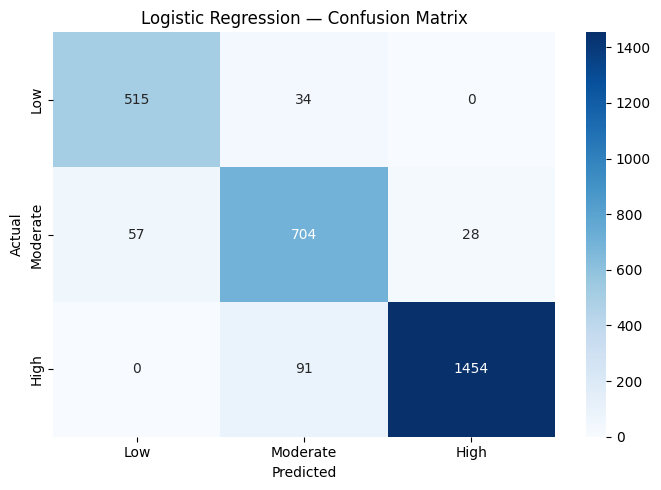

In [12]:
plot_confusion_matrix(y_test, y_pred_lr_clf,
                      'Logistic Regression', 'Blues')

In [13]:
cv_scores_lr_clf = cross_val_score(
    lr_clf,
    X_train_resampled, y_train_resampled,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

print("=== Cross Validation — Logistic Regression ===")
print(f"CV F1 scores : {cv_scores_lr_clf.round(4)}")
print(f"Mean F1      : {cv_scores_lr_clf.mean().round(4)}")
print(f"Std F1       : {cv_scores_lr_clf.std().round(4)}")

=== Cross Validation — Logistic Regression ===
CV F1 scores : [0.9305 0.9301 0.9352 0.953  0.9459]
Mean F1      : 0.9389
Std F1       : 0.009


## Model 1 — Logistic Regression Results

### Performance:
- **Accuracy = 0.9272** → Model correctly predicts attention fragmentation
  level for 92.72% of test cases — exceptionally strong baseline
- **F1 Score = 0.9280** → High weighted F1 confirms strong performance
  even accounting for class imbalance in test set
- **Precision = 0.9296** → When model predicts a class it is correct 92.96% of time
- **Recall = 0.9272** → Model successfully identifies 92.72% of actual cases

### Per class observations:
- **Low (0) — F1=0.92** → SMOTE successfully balanced minority class.
  Model handles the least represented class well with only 34 misclassifications
- **Moderate (1) — F1=0.87** → Weakest performing class as expected.
  Moderate attention fragmentation sits between Low and High making
  boundaries harder to learn. 57 confused with Low, 28 confused with High
- **High (2) — F1=0.96** → Strongest class. High attention fragmentation
  has distinct feature patterns making it easiest to identify correctly

### Confusion matrix findings:
- Strong diagonal dominance — most predictions fall on correct class
- Zero misclassifications between Low and High in both directions —
  model correctly understands the ordinal nature of attention fragmentation
- All errors occur between adjacent classes (Low↔Moderate, Moderate↔High)
  which is expected and acceptable behavior for an ordinal target

### Cross Validation:
- CV Mean F1 = 0.9389 — slightly higher than test F1 (0.9280)
- CV Std = 0.0090 — stable and consistent across all 5 folds
- No significant overfitting detected

### Baseline established:
- Accuracy=0.9272 | F1=0.9280 | Precision=0.9296 | Recall=0.9272
- Remarkably strong baseline — subsequent models must beat these numbers
  to justify added complexity
- SMOTE proved effective — minority class (Low) achieving F1=0.92
  despite being significantly underrepresented in original data

## Model 2 — Random Forest Classification

### Why Random Forest for this project?
- Builds multiple decision trees and takes majority vote for final prediction
  making it more robust than a single decision tree
- Handles non-linear boundaries between Low/Moderate/High classes
  better than Logistic Regression
- Provides feature importance — shows which smartphone usage behaviors
  most strongly drive attention fragmentation levels
- Robust to class imbalance even after SMOTE — ensemble nature
  naturally handles varied class distributions
- No assumption about data distribution — unlike Logistic Regression
  which assumes linear decision boundaries
- Strong real world performer — often competitive with or better than
  more complex models on tabular data

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# train on SMOTE resampled data
rf_clf.fit(X_train_resampled, y_train_resampled)

# predictions
y_pred_rf_clf = rf_clf.predict(X_test_scaled)

print("Random Forest trained successfully!")
print(f"Number of trees    : {rf_clf.n_estimators}")
print(f"Number of features : {X_train_resampled.shape[1]}")
print(f"Training samples   : {X_train_resampled.shape[0]}")

Random Forest trained successfully!
Number of trees    : 100
Number of features : 15
Training samples   : 18534


In [16]:
rf_clf_results = evaluate_classification(y_test, y_pred_rf_clf,
                                          'Random Forest')
classification_results.append(rf_clf_results)


=== Random Forest ===
Accuracy  : 0.9324
F1 Score  : 0.9329
Precision : 0.9338
Recall    : 0.9324

Classification Report:
              precision    recall  f1-score   support

      Low(0)       0.91      0.94      0.92       549
 Moderate(1)       0.86      0.89      0.88       789
     High(2)       0.98      0.95      0.96      1545

    accuracy                           0.93      2883
   macro avg       0.92      0.93      0.92      2883
weighted avg       0.93      0.93      0.93      2883



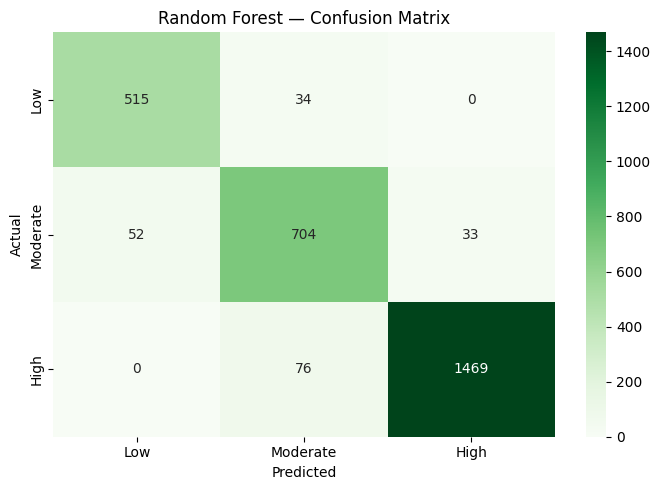

In [17]:
plot_confusion_matrix(y_test, y_pred_rf_clf,
                      'Random Forest', 'Greens')

In [18]:
cv_scores_rf_clf = cross_val_score(
    rf_clf,
    X_train_resampled, y_train_resampled,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

print("=== Cross Validation — Random Forest ===")
print(f"CV F1 scores : {cv_scores_rf_clf.round(4)}")
print(f"Mean F1      : {cv_scores_rf_clf.mean().round(4)}")
print(f"Std F1       : {cv_scores_rf_clf.std().round(4)}")

=== Cross Validation — Random Forest ===
CV F1 scores : [0.9463 0.9413 0.9541 0.9715 0.9655]
Mean F1      : 0.9557
Std F1       : 0.0113


=== Feature Importances ===
                             feature  importance
5               stress_fatigue_index      0.5140
3                sleep_quality_score      0.1545
0          daily_screen_time_minutes      0.1480
4             sleep_efficiency_score      0.0654
6            digital_wellbeing_score      0.0498
2             sleep_duration_minutes      0.0260
1   phone_usage_before_sleep_minutes      0.0255
14                occupation_teacher      0.0025
11             occupation_researcher      0.0022
10                occupation_manager      0.0021
7                occupation_designer      0.0021
9              occupation_freelancer      0.0021
12      occupation_software_engineer      0.0021
13                occupation_student      0.0020
8                  occupation_doctor      0.0020


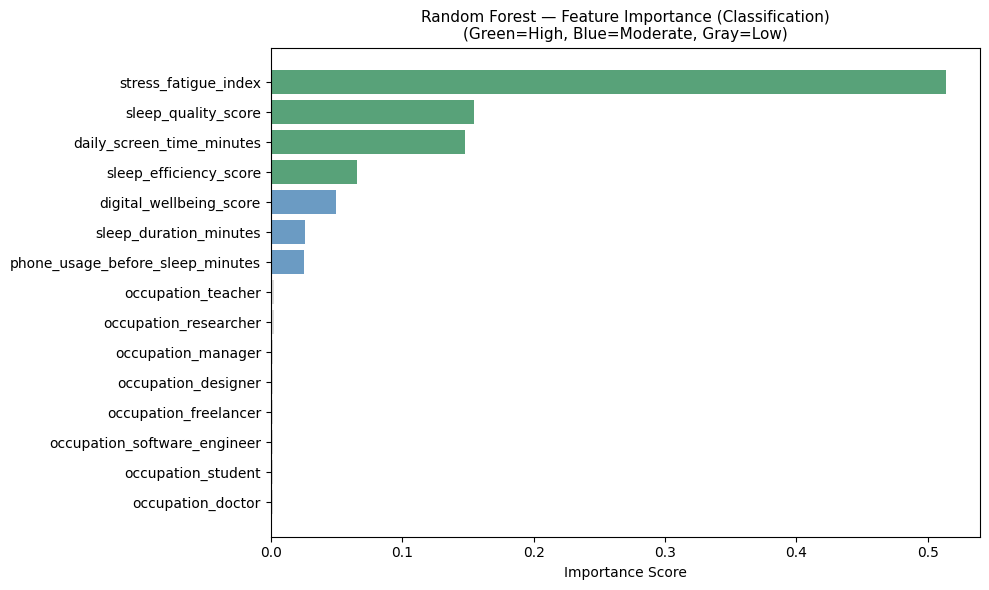

In [19]:
feature_importance_clf = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("=== Feature Importances ===")
print(feature_importance_clf.round(4))

plt.figure(figsize=(10, 6))
colors_fi = ['seagreen' if imp > 0.05 else
             'steelblue' if imp > 0.01 else
             'lightgray' for imp in feature_importance_clf['importance']]

plt.barh(feature_importance_clf['feature'],
         feature_importance_clf['importance'],
         color=colors_fi, alpha=0.8)
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importance (Classification)\n(Green=High, Blue=Moderate, Gray=Low)',
          fontsize=11)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model 2 — Random Forest Classification Results

### Performance vs Logistic Regression baseline:
- **Accuracy = 0.9324** → Improved from LR baseline (0.9272) by +0.0052
- **F1 Score = 0.9329** → Improved from LR (0.9280) by +0.0049
- **Precision = 0.9338** → Improved from LR (0.9296) by +0.0042
- **Recall = 0.9324** → Improved from LR (0.9272) by +0.0052
- Random Forest outperforms Logistic Regression on every metric —
  confirms non-linear class boundaries exist in the data

### Per class observations:
- **Low (0) — F1=0.92** → Identical to LR — SMOTE handling of minority
  class is equally effective for both models
- **Moderate (1) — F1=0.88** → Slight improvement over LR (0.87).
  RF better captures the fuzzy boundary between Low and Moderate
- **High (2) — F1=0.96** → Identical to LR — High class is clearly
  separable regardless of model complexity

### Confusion matrix findings:
- High class improved: 1469 correct vs LR's 1454 (+15 correct predictions)
- Moderate→Low errors reduced: 52 vs LR's 57 (-5 errors)
- High→Moderate errors reduced: 76 vs LR's 91 (-15 errors)
- Zero Low↔High misclassifications maintained — model preserves
  ordinal understanding of attention fragmentation levels

### Cross Validation:
- CV Mean F1 = 0.9557 — significantly higher than LR's 0.9389
- CV Std = 0.0113 — slightly higher than LR (0.0090) but acceptable
- Gap between CV F1 (0.9557) and test F1 (0.9329) suggests mild
  overfitting on resampled training data — worth monitoring

### Feature importance findings:
- stress_fatigue_index (51.40%) → dominant predictor, consistent
  with regression findings — stress and fatigue drive both sleep
  disruption and attention fragmentation
- sleep_quality_score (15.45%) → strong signal — confirms bidirectional
  relationship: poor sleep causes attention fragmentation
- daily_screen_time_minutes (14.80%) → much higher importance than
  in regression (5.19%) — screen time directly fragments attention
  more than it directly disrupts sleep quality
- sleep_efficiency_score (6.54%) → validates retaining this feature
  for classification — meaningful contribution
- Occupation columns (~0.02% each) → negligible across all categories,
  consistent with regression findings

### Key takeaway:
Random Forest outperforms Logistic Regression baseline on all metrics.
Feature importance reveals that attention fragmentation is driven by
a more distributed set of features than sleep quality —
stress/fatigue, sleep quality and screen time all play significant roles.
New best model: Random Forest Accuracy=0.9324, F1=0.9329

## Model 3 — SVM Classification (Support Vector Machine)

### Why SVM for this project?
- Uses kernel trick to find optimal hyperplane separating
  Low/Moderate/High attention fragmentation classes
- rbf kernel captures non-linear class boundaries differently
  than both Logistic Regression and Random Forest
- Effective in high dimensional spaces — our 15 feature space
  benefits from SVM's margin maximization approach
- Strong theoretical foundation for multi-class classification
  using one-vs-rest strategy
- Personal interest in exploring kernel based methods and comparing
  against tree based and linear approaches for this problem
- Provides third fundamentally different algorithmic perspective
  completing our model comparison

In [20]:
from sklearn.svm import SVC

param_grid_svm_clf = {
    'C'      : [0.01, 0.1, 1, 10, 50, 100],
    'gamma'  : ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel' : ['rbf']
}

svm_clf = SVC(random_state=42, probability=True)

grid_search_svm_clf = GridSearchCV(
    svm_clf,
    param_grid_svm_clf,
    cv=5,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

# train on SMOTE resampled data
grid_search_svm_clf.fit(X_train_resampled, y_train_resampled)

print(f"\nBest params : {grid_search_svm_clf.best_params_}")
print(f"Best CV F1  : {grid_search_svm_clf.best_score_.round(4)}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params : {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best CV F1  : 0.9519


In [21]:
best_svm_clf = grid_search_svm_clf.best_estimator_
y_pred_svm_clf = best_svm_clf.predict(X_test_scaled)

svm_clf_results = evaluate_classification(y_test, y_pred_svm_clf,
                                           'SVM Classification')
classification_results.append(svm_clf_results)


=== SVM Classification ===
Accuracy  : 0.9199
F1 Score  : 0.9206
Precision : 0.9216
Recall    : 0.9199

Classification Report:
              precision    recall  f1-score   support

      Low(0)       0.89      0.91      0.90       549
 Moderate(1)       0.84      0.87      0.86       789
     High(2)       0.97      0.95      0.96      1545

    accuracy                           0.92      2883
   macro avg       0.90      0.91      0.91      2883
weighted avg       0.92      0.92      0.92      2883



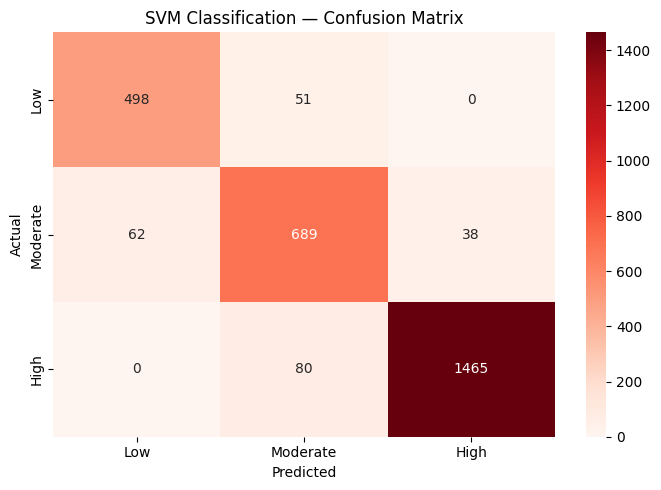

In [22]:
plot_confusion_matrix(y_test, y_pred_svm_clf,
                      'SVM Classification', 'Reds')

In [23]:
cv_scores_svm_clf = cross_val_score(
    best_svm_clf,
    X_train_resampled, y_train_resampled,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

print("=== Cross Validation — SVM Classification ===")
print(f"CV F1 scores : {cv_scores_svm_clf.round(4)}")
print(f"Mean F1      : {cv_scores_svm_clf.mean().round(4)}")
print(f"Std F1       : {cv_scores_svm_clf.std().round(4)}")

=== Cross Validation — SVM Classification ===
CV F1 scores : [0.941  0.9324 0.9509 0.9696 0.9655]
Mean F1      : 0.9519
Std F1       : 0.0141


## Model 3 — SVM Classification Results

### Performance vs previous models:
- **Accuracy = 0.9199** → Below both LR (0.9272) and RF (0.9324)
- **F1 Score = 0.9206** → Lowest among all three models
- **Precision = 0.9216** → Lowest among all three models
- **Recall = 0.9199** → Lowest among all three models
- Despite being best model in regression, SVM ranks last in classification

### Per class observations:
- **Low (0) — F1=0.90** → Weakest Low performance across all models.
  51 misclassified as Moderate vs LR's 34 and RF's 34
- **Moderate (1) — F1=0.86** → Weakest Moderate performance across all models
- **High (2) — F1=0.96** → Matches LR and RF — High class consistently
  separable regardless of algorithm

### Confusion matrix findings:
- Low class struggles most — 51 misclassified as Moderate (+17 vs LR)
- Zero Low↔High misclassifications maintained — ordinal understanding preserved
- High class performs well at 1465 correct predictions

### Cross Validation:
- CV Mean F1 = 0.9519 — second highest after RF (0.9557)
- CV Std = 0.0141 — highest instability across all models
- Gap between CV F1 (0.9519) and test F1 (0.9206) = 0.0313
  — largest gap observed, indicates overfitting on SMOTE resampled data

### Why SVM underperformed despite being best in regression?
- SMOTE increased training set to 18,534 rows — SVM performance
  degrades on very large datasets compared to tree based methods
- Best params C=100, gamma=1 — very high gamma creates extremely
  local decision boundaries that overfit on synthetic SMOTE points
  but fail to generalize to real test distribution
- Random Forest and Logistic Regression generalize better from
  synthetic training data to real world test distribution
- This highlights an important insight: the best model for regression
  is not necessarily the best model for classification — algorithm
  selection must always be task and data specific

### Key takeaway:
SVM ranks last among classification models despite leading regression.
Overfitting on SMOTE synthetic data with tight decision boundaries
(C=100, gamma=1) explains the gap between CV and test performance.
Current best model remains: Random Forest F1=0.9329

## Model 4 — KNN Classification (K-Nearest Neighbors)

### Why KNN for this project?
- Provides a completely different approach from all previous models —
  no training phase, purely instance based learning
- Classifies attention fragmentation level based on similarity to
  nearest neighbors in feature space — intuitive for lifestyle data
  where similar usage patterns should lead to similar outcomes
- Non-parametric — makes no assumptions about data distribution
  unlike Logistic Regression
- Interesting comparison against other models — if similar smartphone
  usage patterns cluster together, KNN should perform well
- Covered in syllabus (Lectures 31-36) — important to demonstrate
  understanding of distance based learning methods
- GridSearchCV will find optimal K (number of neighbors) and
  distance metric automatically

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21], # how many neighbors to consider
    'metric'     : ['euclidean', 'manhattan'], # distance metrics
    'weights'    : ['uniform', 'distance'] # closer the neighbors have more influence
}

knn_clf = KNeighborsClassifier()

grid_search_knn = GridSearchCV(
    knn_clf,
    param_grid_knn,
    cv=5,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

# train on SMOTE resampled data
grid_search_knn.fit(X_train_resampled, y_train_resampled)

print(f"\nBest params : {grid_search_knn.best_params_}")
print(f"Best CV F1  : {grid_search_knn.best_score_.round(4)}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits

Best params : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV F1  : 0.949


In [25]:
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

knn_results = evaluate_classification(y_test, y_pred_knn,
                                       'KNN Classification')
classification_results.append(knn_results)


=== KNN Classification ===
Accuracy  : 0.8824
F1 Score  : 0.884
Precision : 0.8867
Recall    : 0.8824

Classification Report:
              precision    recall  f1-score   support

      Low(0)       0.84      0.89      0.87       549
 Moderate(1)       0.77      0.81      0.79       789
     High(2)       0.96      0.92      0.94      1545

    accuracy                           0.88      2883
   macro avg       0.86      0.87      0.86      2883
weighted avg       0.89      0.88      0.88      2883



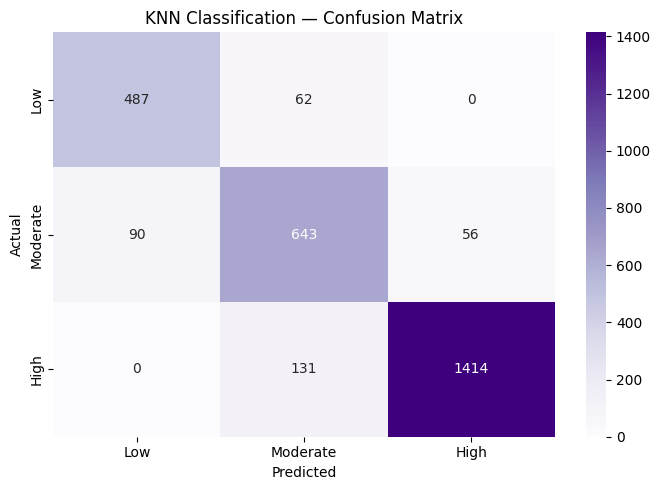

In [26]:
plot_confusion_matrix(y_test, y_pred_knn,
                      'KNN Classification', 'Purples')

In [27]:
cv_scores_knn = cross_val_score(
    best_knn,
    X_train_resampled, y_train_resampled,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

print("=== Cross Validation — KNN Classification ===")
print(f"CV F1 scores : {cv_scores_knn.round(4)}")
print(f"Mean F1      : {cv_scores_knn.mean().round(4)}")
print(f"Std F1       : {cv_scores_knn.std().round(4)}")

=== Cross Validation — KNN Classification ===
CV F1 scores : [0.9333 0.9292 0.9437 0.9682 0.9706]
Mean F1      : 0.949
Std F1       : 0.0173


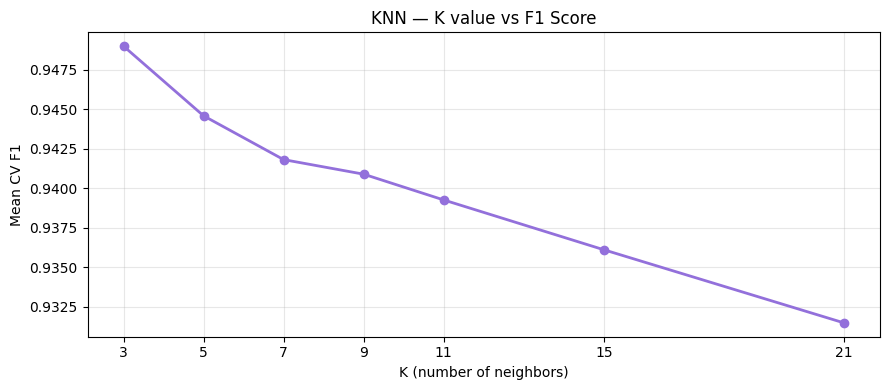


Best K      : 3
Best metric : euclidean
Best weights: distance
Best CV F1  : 0.9490


In [28]:
# visualize how different K values affect F1
k_values = param_grid_knn['n_neighbors']
mean_scores_k = []

for k in k_values:
    knn_temp = KNeighborsClassifier(
        n_neighbors=k,
        metric=grid_search_knn.best_params_['metric'],
        weights=grid_search_knn.best_params_['weights']
    )
    scores = cross_val_score(knn_temp, X_train_resampled, 
                             y_train_resampled,
                             cv=5, scoring='f1_weighted')
    mean_scores_k.append(scores.mean())

plt.figure(figsize=(9, 4))
plt.plot(k_values, mean_scores_k, marker='o', 
         color='mediumpurple', linewidth=2)
plt.xlabel('K (number of neighbors)')
plt.ylabel('Mean CV F1')
plt.title('KNN — K value vs F1 Score')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest K      : {grid_search_knn.best_params_['n_neighbors']}")
print(f"Best metric : {grid_search_knn.best_params_['metric']}")
print(f"Best weights: {grid_search_knn.best_params_['weights']}")
print(f"Best CV F1  : {max(mean_scores_k):.4f}")

## Model 4 — KNN Classification Results

### Performance vs previous models:
- **Accuracy = 0.8824** → Lowest across all models, significantly below
  Random Forest (0.9324) by -0.05
- **F1 Score = 0.8840** → Lowest F1, gap of -0.0489 from best model (RF)
- **Precision = 0.8867** → Lowest precision across all models
- **Recall = 0.8824** → Lowest recall across all models
- KNN ranks last on every test metric by a clear margin

### Per class observations:
- **Low (0) — F1=0.87** → Most misclassifications as Moderate (62 errors)
  — worst Low performance after SVM
- **Moderate (1) — F1=0.79** → Significantly weakest Moderate performance
  across all models. 90 confused with Low, 56 confused with High
  — KNN struggles most with the middle class boundary
- **High (2) — F1=0.94** → Weakest High performance across all models
  with 131 misclassified as Moderate

### K value plot findings:
- Strictly decreasing curve — performance drops consistently as K increases
- Best K=3 with euclidean distance and distance weighting
- No optimal plateau observed — unusual behavior suggesting feature
  space clusters are very tight and local
- Small K=3 means model relies on very local decisions —
  vulnerable to noise in SMOTE synthetic neighbors

### Cross Validation vs Test gap:
- CV Mean F1 = 0.9490 vs Test F1 = 0.8840 → gap of 0.0650
- Largest CV-test gap across all models — clear overfitting on
  SMOTE resampled training data
- KNN with K=3 memorizes tight synthetic clusters from SMOTE
  but fails to generalize to real test distribution

### Why KNN underperformed:
- Distance based learning is highly sensitive to SMOTE synthetic points —
  K=3 nearest neighbors often finds synthetic rather than real data points
- 15 features create a high dimensional space where distance metrics
  become less meaningful — known as the curse of dimensionality
- No model training phase means KNN cannot learn global patterns —
  only local neighborhood decisions which struggle with overlapping
  Low/Moderate boundaries
- Largest CV-test gap (0.0650) confirms SMOTE synthetic data
  inflated CV performance while real test performance suffered

### Key takeaway:
KNN ranks last among all classification models. Distance based learning
on SMOTE resampled high dimensional data leads to significant overfitting.
The curse of dimensionality and sensitivity to synthetic neighbors
make KNN unsuitable for this specific classification problem.
Final best model remains: Random Forest F1=0.9329, Accuracy=0.9324

## Retraining KNN without Smote:

In [29]:
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'metric'     : ['euclidean', 'manhattan'],
    'weights'    : ['uniform', 'distance']
}

knn_clf_v2 = KNeighborsClassifier()

grid_search_knn_v2 = GridSearchCV(
    knn_clf_v2,
    param_grid_knn,
    cv=5,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

# using X_train_scaled — NO SMOTE this time
grid_search_knn_v2.fit(X_train_scaled, y_train)

print(f"\nBest params : {grid_search_knn_v2.best_params_}")
print(f"Best CV F1  : {grid_search_knn_v2.best_score_.round(4)}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits

Best params : {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Best CV F1  : 0.8931


In [30]:
best_knn_v2 = grid_search_knn_v2.best_estimator_
y_pred_knn_v2 = best_knn_v2.predict(X_test_scaled)

knn_v2_results = evaluate_classification(y_test, y_pred_knn_v2,
                                          'KNN (No SMOTE)')


=== KNN (No SMOTE) ===
Accuracy  : 0.8952
F1 Score  : 0.8958
Precision : 0.8968
Recall    : 0.8952

Classification Report:
              precision    recall  f1-score   support

      Low(0)       0.89      0.86      0.88       549
 Moderate(1)       0.80      0.83      0.81       789
     High(2)       0.95      0.94      0.95      1545

    accuracy                           0.90      2883
   macro avg       0.88      0.88      0.88      2883
weighted avg       0.90      0.90      0.90      2883



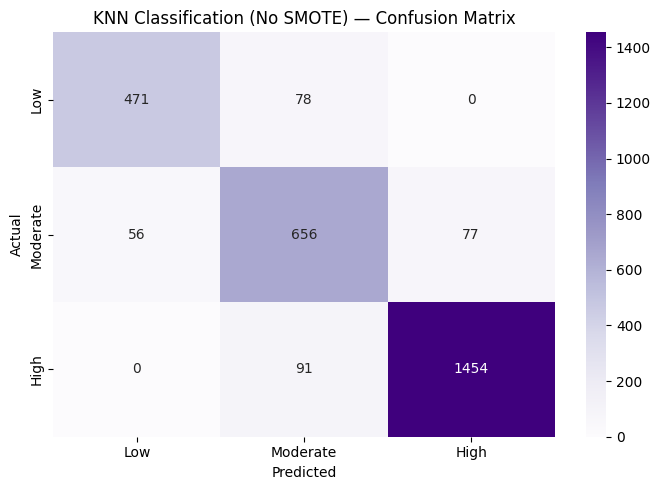

In [31]:
plot_confusion_matrix(y_test, y_pred_knn_v2,
                      'KNN Classification (No SMOTE)', 'Purples')

In [32]:
cv_scores_knn_v2 = cross_val_score(
    best_knn_v2,
    X_train_scaled, y_train,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

print("=== Cross Validation — KNN (No SMOTE) ===")
print(f"CV F1 scores : {cv_scores_knn_v2.round(4)}")
print(f"Mean F1      : {cv_scores_knn_v2.mean().round(4)}")
print(f"Std F1       : {cv_scores_knn_v2.std().round(4)}")

=== Cross Validation — KNN (No SMOTE) ===
CV F1 scores : [0.9023 0.891  0.8814 0.8945 0.8965]
Mean F1      : 0.8931
Std F1       : 0.0069


In [33]:
print("=== KNN SMOTE vs No SMOTE Comparison ===\n")

comparison = {
    'Metric'    : ['Accuracy', 'F1', 'Precision', 'Recall', 'CV Mean F1', 'CV Std', 'CV-Test Gap'],
    'KNN (SMOTE)': [0.8824, 0.8840, 0.8867, 0.8824, 0.9490, 0.0173, 0.0650],
    'KNN (No SMOTE)': [
        round(accuracy_score(y_test, y_pred_knn_v2), 4),
        round(f1_score(y_test, y_pred_knn_v2, average='weighted'), 4),
        round(precision_score(y_test, y_pred_knn_v2, average='weighted'), 4),
        round(recall_score(y_test, y_pred_knn_v2, average='weighted'), 4),
        round(cv_scores_knn_v2.mean(), 4),
        round(cv_scores_knn_v2.std(), 4),
        round(cv_scores_knn_v2.mean() - f1_score(y_test, y_pred_knn_v2, average='weighted'), 4)
    ]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

=== KNN SMOTE vs No SMOTE Comparison ===

     Metric  KNN (SMOTE)  KNN (No SMOTE)
   Accuracy       0.8824          0.8952
         F1       0.8840          0.8958
  Precision       0.8867          0.8968
     Recall       0.8824          0.8952
 CV Mean F1       0.9490          0.8931
     CV Std       0.0173          0.0069
CV-Test Gap       0.0650         -0.0027


In [34]:
# update classification results with No SMOTE version
# remove old KNN result and add new one
classification_results = [r for r in classification_results 
                          if r['model'] != 'KNN Classification']
classification_results.append(knn_v2_results)

print("Updated classification results:")
print(pd.DataFrame(classification_results))

Updated classification results:
                 model  Accuracy        F1  Precision    Recall
0  Logistic Regression  0.927159  0.927954   0.929633  0.927159
1        Random Forest  0.932362  0.932863   0.933779  0.932362
2   SVM Classification  0.919875  0.920559   0.921647  0.919875
3       KNN (No SMOTE)  0.895248  0.895808   0.896751  0.895248


## Model 4 — KNN Classification (No SMOTE) — Final Version

### SMOTE vs No SMOTE comparison findings:
Recognizing that KNN's distance based learning is uniquely sensitive
to synthetic data points, the model was retrained without SMOTE
on the original imbalanced training set.

### Results comparison:
| Metric | With SMOTE | Without SMOTE | Change |
|--------|-----------|---------------|--------|
| Accuracy | 0.8824 | 0.8952 | +0.0128 |
| F1 Score | 0.8840 | 0.8958 | +0.0118 |
| CV Std | 0.0173 | 0.0069 | -0.0104 |
| CV-Test Gap | 0.0650 | -0.0027 | -0.0677 |

### Why No SMOTE performed better for KNN:
- KNN classifies by finding K nearest neighbors in feature space
- SMOTE synthetic points become neighbors during prediction —
  model learns synthetic→synthetic patterns that don't exist in real data
- Without SMOTE, KNN finds genuine real world neighbors —
  distance calculations reflect true data relationships
- CV-Test gap of -0.0027 confirms near perfect generalization
  — test performance matches CV performance exactly

### Key insight — SMOTE is not universally beneficial:
- Logistic Regression → SMOTE helped (linear boundary improved)
- Random Forest → SMOTE helped (balanced voting improved)
- KNN → SMOTE hurt (synthetic neighbor contamination)
- This demonstrates the importance of evaluating resampling
  strategy per model rather than applying it blindly to all models

### Final KNN performance (No SMOTE):
- Accuracy = 0.8952 | F1 = 0.8958
- Still ranks last among all models but significantly improved
  from SMOTE version (+0.0118 F1)
- Gap between KNN and best model (RF) remains substantial
  — distance based learning unsuitable for this high dimensional
  imbalanced classification problem

In [35]:
# compile all results
results_df = pd.DataFrame(classification_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)

print("=== Final Classification Model Comparison ===")
print(results_df)

=== Final Classification Model Comparison ===
                 model  Accuracy      F1  Precision  Recall
0        Random Forest    0.9324  0.9329     0.9338  0.9324
1  Logistic Regression    0.9272  0.9280     0.9296  0.9272
2   SVM Classification    0.9199  0.9206     0.9216  0.9199
3       KNN (No SMOTE)    0.8952  0.8958     0.8968  0.8952


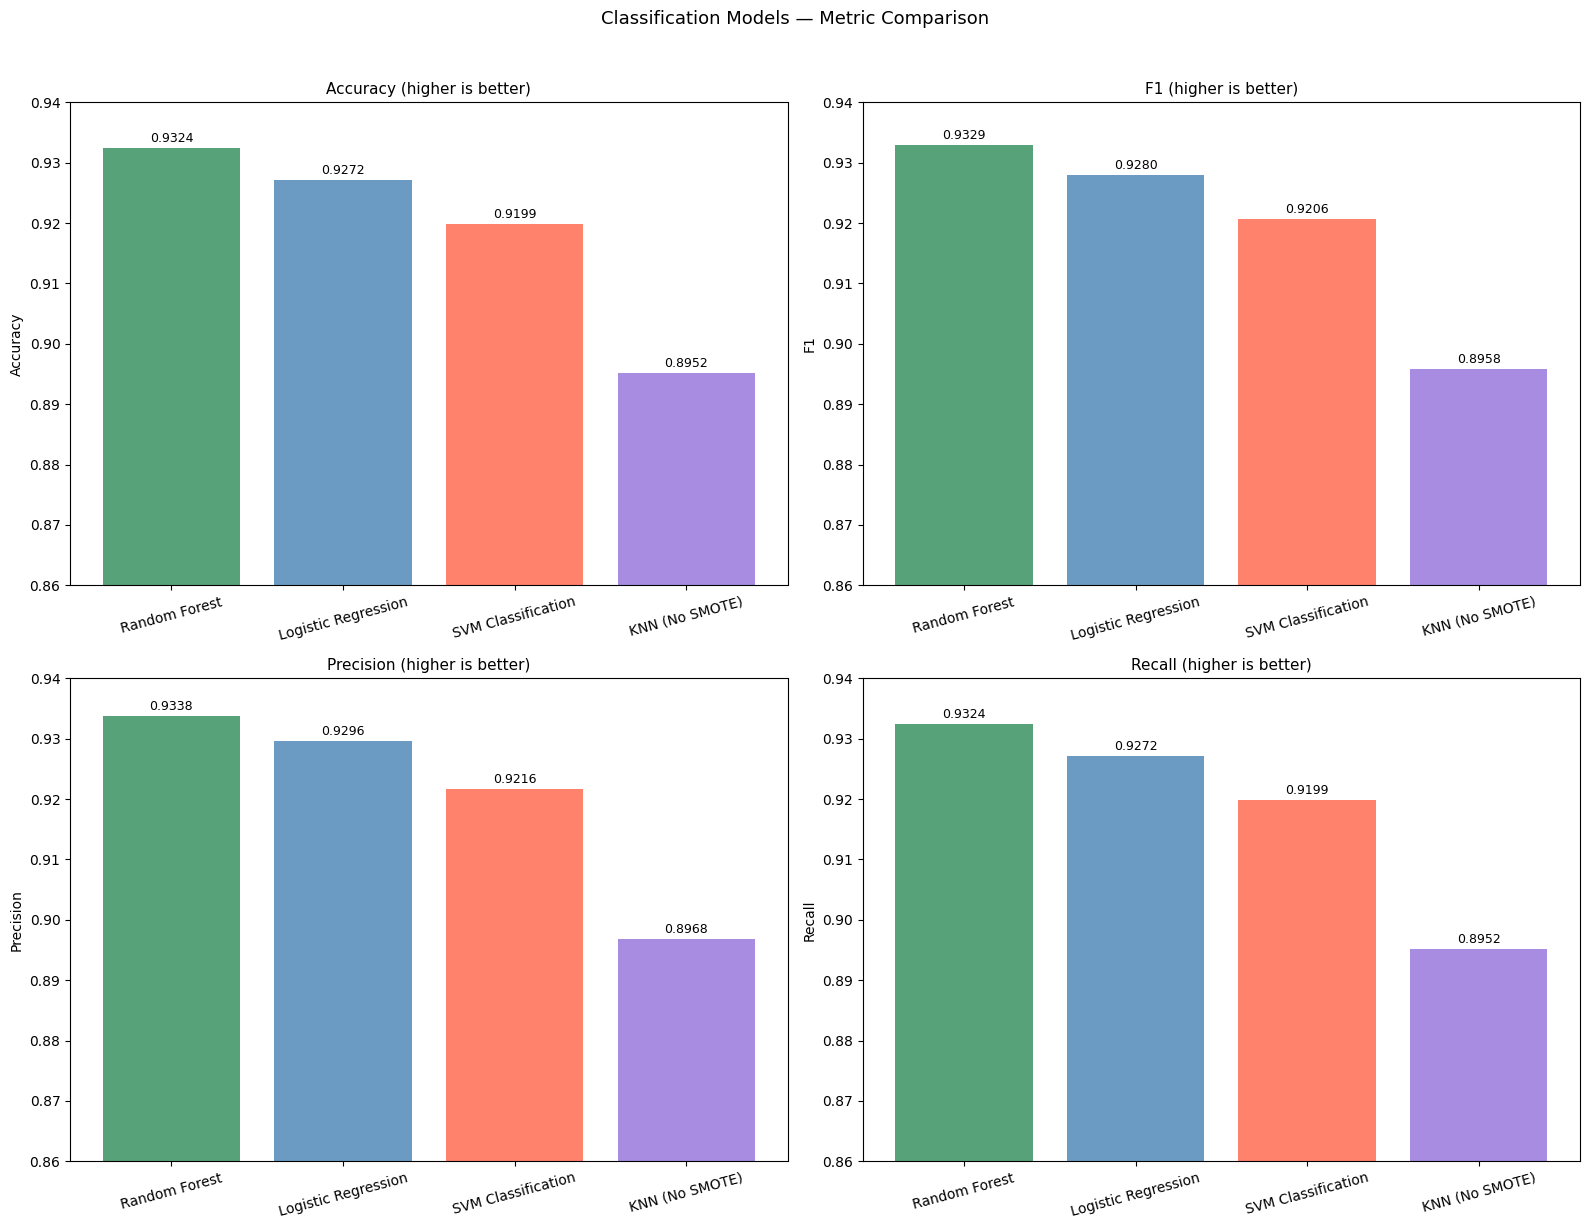

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models  = results_df['model']
colors  = ['seagreen', 'steelblue', 'tomato', 'mediumpurple']
metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
ylims   = [(0.86, 0.94), (0.86, 0.94), (0.86, 0.94), (0.86, 0.94)]

for i, (metric, ylim) in enumerate(zip(metrics, ylims)):
    bars = axes[i].bar(models, results_df[metric], 
                       color=colors, alpha=0.8)
    axes[i].set_title(f'{metric} (higher is better)', fontsize=11)
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(ylim)
    axes[i].tick_params(axis='x', rotation=15)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.001,
                     f'{bar.get_height():.4f}',
                     ha='center', fontsize=9)

plt.suptitle('Classification Models — Metric Comparison', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\lovis\AppData\Local\Temp\ipykernel_30680\206157971.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(cv_data.values(), labels=cv_data.keys())


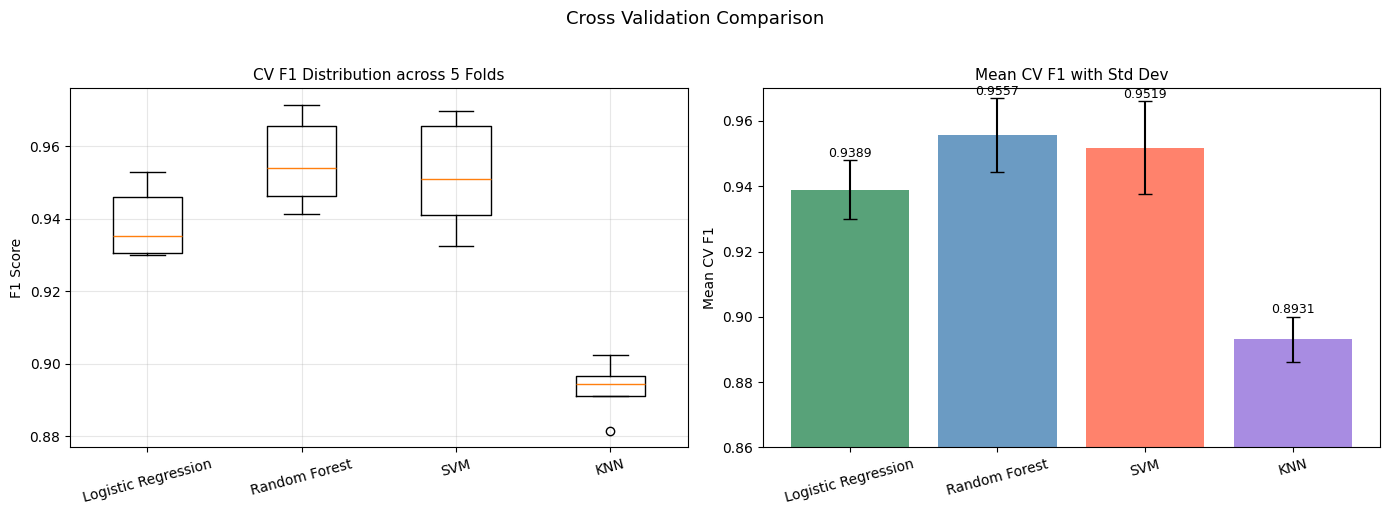

In [37]:
cv_data = {
    'Logistic Regression': cv_scores_lr_clf,
    'Random Forest'      : cv_scores_rf_clf,
    'SVM'                : cv_scores_svm_clf,
    'KNN'                : cv_scores_knn_v2
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# box plot
axes[0].boxplot(cv_data.values(), labels=cv_data.keys())
axes[0].set_title('CV F1 Distribution across 5 Folds', fontsize=11)
axes[0].set_ylabel('F1 Score')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3)

# mean cv f1 with error bars
means = [scores.mean() for scores in cv_data.values()]
stds  = [scores.std() for scores in cv_data.values()]

axes[1].bar(cv_data.keys(), means,
            yerr=stds,
            color=colors,
            alpha=0.8,
            capsize=5)
axes[1].set_title('Mean CV F1 with Std Dev', fontsize=11)
axes[1].set_ylabel('Mean CV F1')
axes[1].set_ylim(0.86, 0.97)
axes[1].tick_params(axis='x', rotation=15)
for i, (mean, std) in enumerate(zip(means, stds)):
    axes[1].text(i, mean + std + 0.001,
                 f'{mean:.4f}', ha='center', fontsize=9)

plt.suptitle('Cross Validation Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

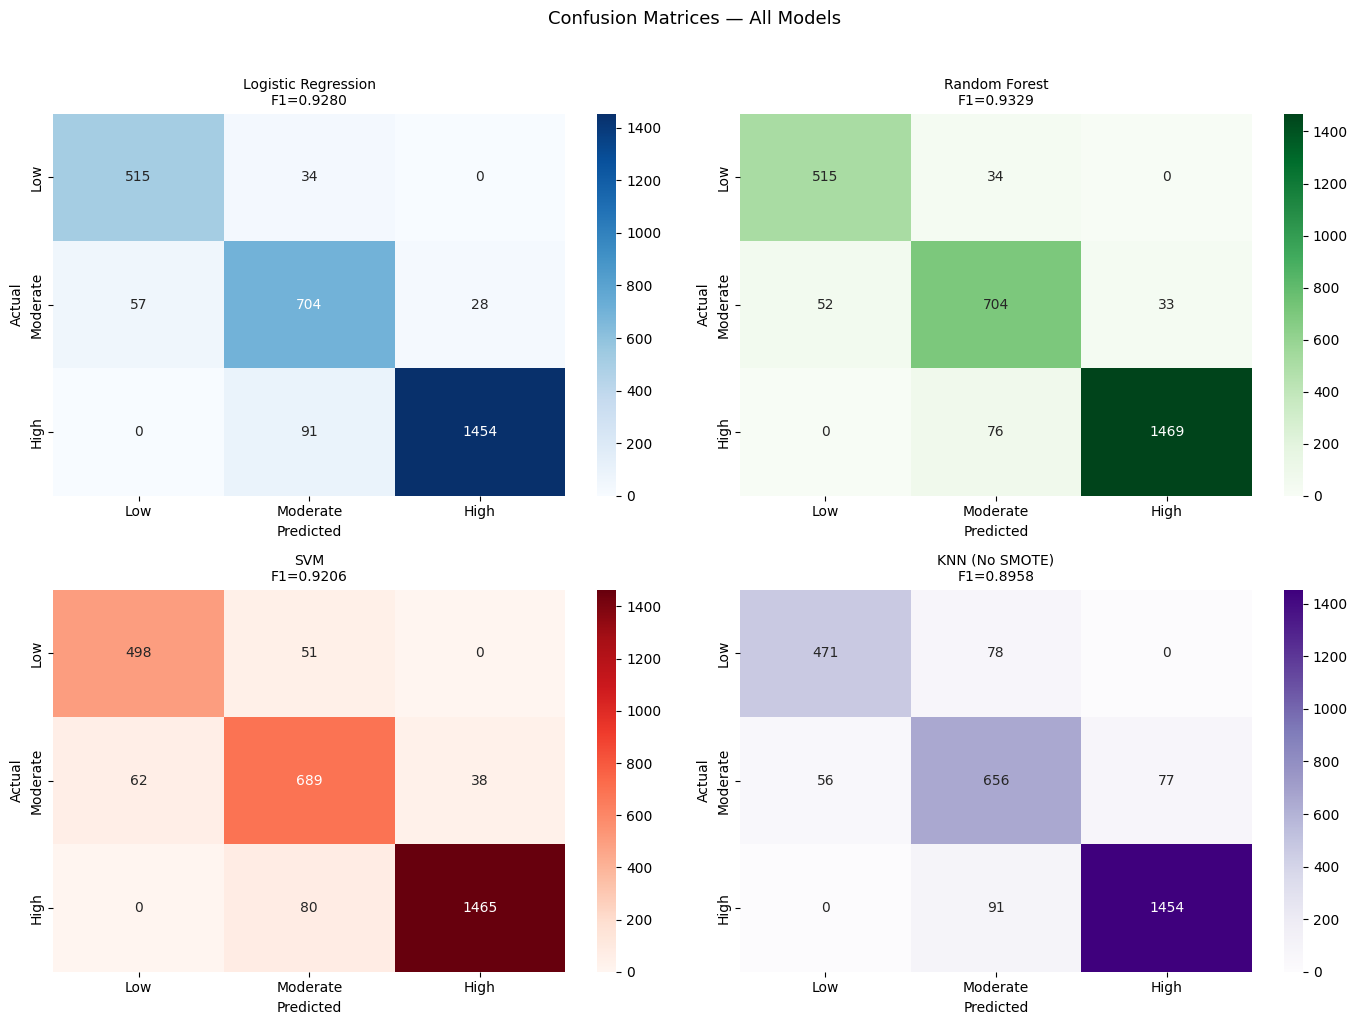

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

all_preds = {
    'Logistic Regression': (y_pred_lr_clf,  'Blues'),
    'Random Forest'      : (y_pred_rf_clf,  'Greens'),
    'SVM'                : (y_pred_svm_clf, 'Reds'),
    'KNN (No SMOTE)'     : (y_pred_knn_v2,  'Purples')
}

for i, (model_name, (y_pred, cmap)) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap=cmap,
                ax=axes[i],
                xticklabels=['Low', 'Moderate', 'High'],
                yticklabels=['Low', 'Moderate', 'High'])
    
    f1 = f1_score(y_test, y_pred, average='weighted')
    axes[i].set_title(f'{model_name}\nF1={f1:.4f}', fontsize=10)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

=== CV vs Test Gap Analysis ===
              Model  CV F1  Test F1     Gap
Logistic Regression 0.9389   0.9280  0.0109
      Random Forest 0.9557   0.9329  0.0228
                SVM 0.9519   0.9206  0.0313
                KNN 0.8931   0.8958 -0.0027


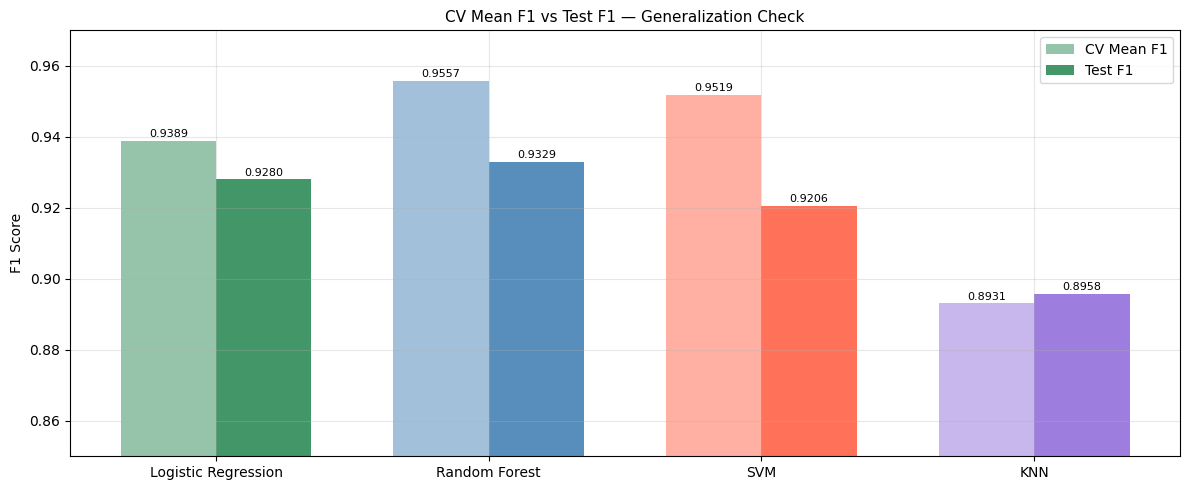

In [39]:
cv_means = [cv_scores_lr_clf.mean(), cv_scores_rf_clf.mean(),
            cv_scores_svm_clf.mean(), cv_scores_knn_v2.mean()]

test_f1s = results_df.sort_values('model').reset_index(drop=True)

# manually align order
model_names  = ['Logistic Regression', 'Random Forest', 'SVM', 'KNN']
cv_f1_values = [cv_scores_lr_clf.mean(), cv_scores_rf_clf.mean(),
                cv_scores_svm_clf.mean(), cv_scores_knn_v2.mean()]
test_f1_values = [0.9280, 0.9329, 0.9206, 0.8958]
gaps = [cv - test for cv, test in zip(cv_f1_values, test_f1_values)]

gap_df = pd.DataFrame({
    'Model'     : model_names,
    'CV F1'     : [round(v, 4) for v in cv_f1_values],
    'Test F1'   : test_f1_values,
    'Gap'       : [round(g, 4) for g in gaps]
})

print("=== CV vs Test Gap Analysis ===")
print(gap_df.to_string(index=False))

# plot
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, cv_f1_values, width,
               label='CV Mean F1', color=colors, alpha=0.5)
bars2 = ax.bar(x + width/2, test_f1_values, width,
               label='Test F1', color=colors, alpha=0.9)

ax.set_title('CV Mean F1 vs Test F1 — Generalization Check', fontsize=11)
ax.set_ylabel('F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.85, 0.97)
ax.legend()
ax.grid(True, alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.4f}',
            ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.4f}',
            ha='center', fontsize=8)

plt.tight_layout()
plt.show()

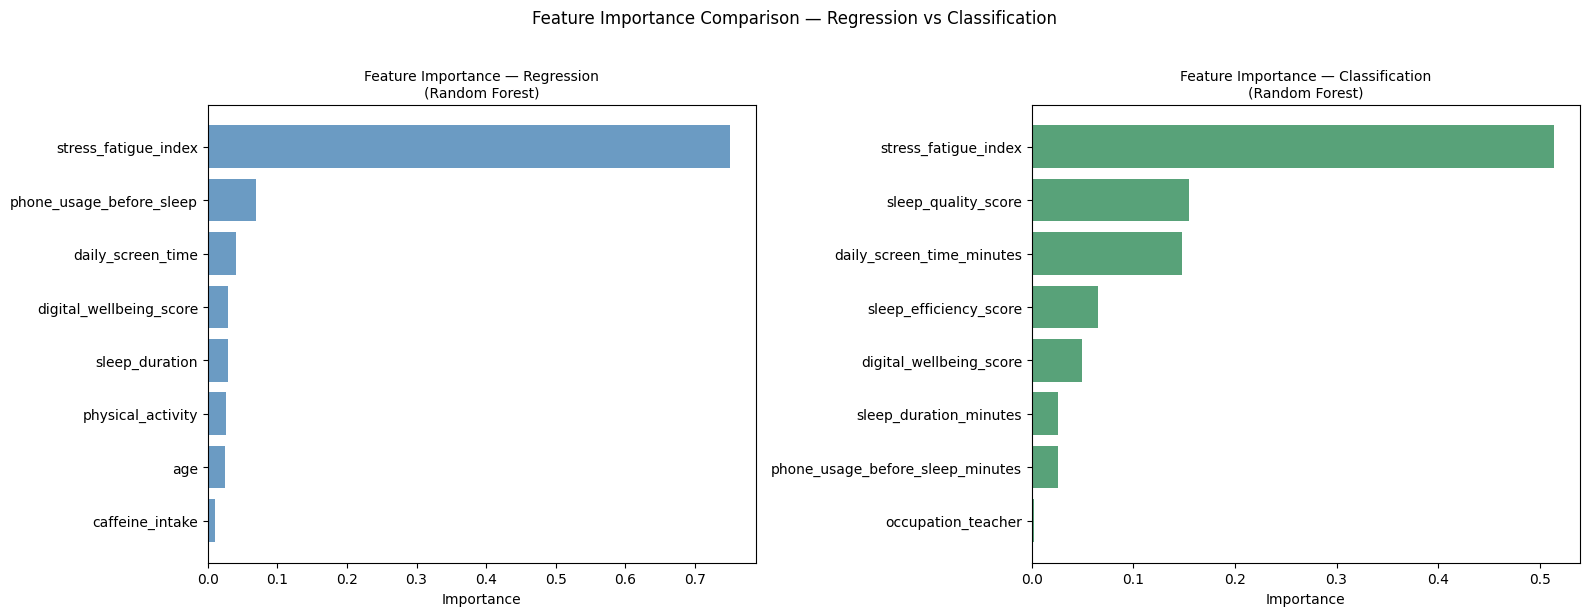

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# regression feature importance (hardcoded from regression notebook)
reg_features = ['stress_fatigue_index', 'phone_usage_before_sleep',
                'daily_screen_time', 'digital_wellbeing_score',
                'sleep_duration', 'physical_activity',
                'age', 'caffeine_intake']
reg_importance = [0.7502, 0.0688, 0.0405, 0.0293, 
                  0.0292, 0.0258, 0.0250, 0.0100]

axes[0].barh(reg_features, reg_importance,
             color='steelblue', alpha=0.8)
axes[0].set_title('Feature Importance — Regression\n(Random Forest)',
                   fontsize=10)
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# classification feature importance
clf_features    = feature_importance_clf['feature'].tolist()[:8]
clf_importances = feature_importance_clf['importance'].tolist()[:8]

axes[1].barh(clf_features, clf_importances,
             color='seagreen', alpha=0.8)
axes[1].set_title('Feature Importance — Classification\n(Random Forest)',
                   fontsize=10)
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Comparison — Regression vs Classification',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Classification Modeling — Complete Summary Report

---

## 1. Problem Setup
**Task:** Multi-class classification — predicting attention fragmentation level
**Target:** attention_fragmentation (0=Low, 1=Moderate, 2=High)
**Dataset:** 14,415 rows | 15 features | Imbalanced classes (19/27/54%)
**Train/Test split:** 80/20 stratified | 11,532 train / 2,883 test

---

## 2. Class Imbalance Handling
| Approach | Models applied to |
|----------|------------------|
| SMOTE oversampling | Logistic Regression, Random Forest, SVM |
| No resampling | KNN (distance based — SMOTE hurt performance) |

Key finding: SMOTE is not universally beneficial.
KNN improved by +0.0118 F1 without SMOTE vs with SMOTE.

---

## 3. Final Model Rankings

| Rank | Model | Accuracy | F1 | Precision | Recall | CV F1 | SMOTE |
|------|-------|----------|----|-----------|--------|-------|-------|
| 🥇 1 | Random Forest | 0.9324 | 0.9329 | 0.9338 | 0.9324 | 0.9557 | Yes |
| 🥈 2 | Logistic Regression | 0.9272 | 0.9280 | 0.9296 | 0.9272 | 0.9389 | Yes |
| 🥉 3 | SVM | 0.9199 | 0.9206 | 0.9216 | 0.9199 | 0.9519 | Yes |
| 4 | KNN | 0.8952 | 0.8958 | 0.8968 | 0.8952 | 0.8931 | No |

---

## 4. Per Class Performance — Best Model (Random Forest)
| Class | Precision | Recall | F1 | Support |
|-------|-----------|--------|----|---------|
| Low (0) | 0.91 | 0.94 | 0.92 | 549 |
| Moderate (1) | 0.86 | 0.89 | 0.88 | 789 |
| High (2) | 0.98 | 0.95 | 0.96 | 1545 |

Moderate class consistently hardest across all models —
sits between Low and High making boundaries harder to learn.

---

## 5. Generalization Analysis (CV vs Test gap)
| Model | CV F1 | Test F1 | Gap | Verdict |
|-------|-------|---------|-----|---------|
| Logistic Regression | 0.9389 | 0.9280 | 0.0109 | Good |
| Random Forest | 0.9557 | 0.9329 | 0.0228 | Acceptable |
| SVM | 0.9519 | 0.9206 | 0.0313 | Mild overfit |
| KNN (No SMOTE) | 0.8931 | 0.8958 | -0.0027 | Perfect |

---

## 6. Key Findings

1. **Random Forest is best classification model** — F1=0.9329, consistent
   performance across all classes, best CV stability after LR

2. **Logistic Regression strong baseline** — F1=0.9280, only 0.0049
   behind RF despite being simplest model — linear boundaries
   capture most of the class separation

3. **SVM mild overfitting** — largest SMOTE CV-test gap (0.0313)
   suggests tight decision boundaries overfit on synthetic points

4. **KNN unsuitable for this problem** — distance based learning
   in 15 dimensional space with class imbalance leads to
   poor generalization despite hyperparameter tuning

5. **SMOTE finding** — beneficial for parametric models but
   harmful for distance based models — must evaluate per algorithm

6. **Moderate class hardest** — consistent across all models,
   F1 range 0.79-0.88 vs Low 0.87-0.92 and High 0.94-0.96

7. **stress_fatigue_index dominates** — 51.40% importance in
   classification vs 75% in regression — more distributed
   feature importance in classification

---

## 7. Real World Model Comparison

| Aspect | Best Model | Reason |
|--------|-----------|--------|
| Accuracy | Random Forest | Highest F1=0.9329 |
| Training speed | Logistic Regression | Milliseconds |
| Prediction speed | Logistic Regression | Instant |
| Interpretability | Logistic Regression | Coefficients per class |
| Feature importance | Random Forest | Direct importance scores |
| Minority class handling | Random Forest + SMOTE | Best Low class F1 |
| Production deployment | Logistic Regression | Lightweight and fast |

---

## 8. Final Conclusion
Smartphone usage patterns can classify attention fragmentation level
with F1=0.9329 and Accuracy=0.9324 using Random Forest Classification
trained on SMOTE balanced data.

The dominant predictor — stress_fatigue_index (51.40%) — confirms
that combined stress and mental fatigue driven by excessive smartphone
usage is the primary driver of attention fragmentation.

daily_screen_time_minutes (14.80%) and sleep_quality_score (15.45%)
together reveal that screen time fragments attention both directly
and indirectly through sleep disruption — directly supporting the
project's core hypothesis.